Updated model to modify for normalization N and baseline B.

In [135]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [136]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.rg1_refactor import load_default_chrom_configs

config, _ = load_default_chrom_configs()

real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1)

Initializing N using config H.
Initializing B using timepoint 0


###### 

In [156]:
real_deconv1.config.alpha = 0
real_deconv1.config.params_dic.update({
 'mu0': 5.95086178727135,
 'delta': 3.5420424946663758,
 'sigma0': 4.574125731433994,
 'sigmav': 0.1041649693276692,
 'lambda': 65.82132480815547,
 'gamma1': 0.4618683933074595,
 'gamma2': 0.6961471064538352,
 'halted': 1.030819214491829e-06,
 'alpha': 0})

real_deconv1.config.update_timepoints()
real_deconv1.config.calculate_H()
real_deconv1.config.params_dic

{'mu0': 5.95086178727135,
 'delta': 3.5420424946663758,
 'sigma0': 4.574125731433994,
 'sigmav': 0.1041649693276692,
 'lambda': 65.82132480815547,
 'gamma1': 0.4618683933074595,
 'gamma2': 0.6961471064538352,
 'halted': 1.030819214491829e-06,
 'alpha': 0}

In [157]:
real_deconv1.setup_deconvolution(real_deconv1.config)
real_deconv1.iterative_deconvolution_updates(1)

Initializing N using config H.
30.40078953451119 45.82132480815547
30.40078953451119 45.82132480815547
30.40078953451119 45.82132480815547
30.40078953451119 45.82132480815547
Initializing B using timepoint 0
Iteration 0
30.40078953451119 45.82132480815547
30.40078953451119 45.82132480815547
0/368 - 00:00:00.002
100/368 - 00:00:00.045
200/368 - 00:00:00.082
300/368 - 00:00:00.119
0.007840461919881548
Iteration completed 00:00:00.246, rn=0.007840461919881548


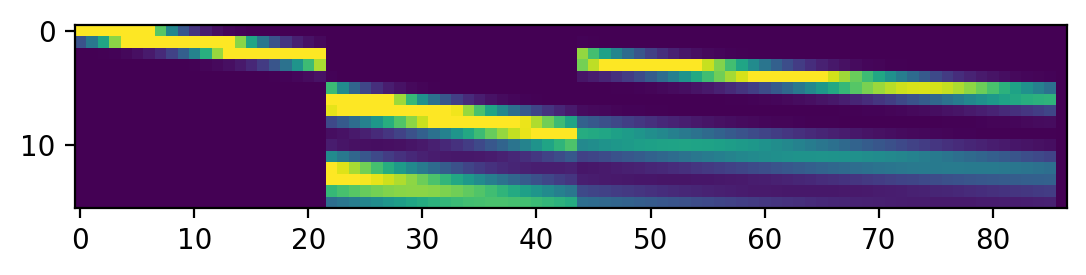

In [158]:
plt.imshow(real_deconv1.config.H, vmax=0.05)

In [160]:
from src.optimize_H import ParameterOptimizer

In [159]:
timepoints = config.timepoints
initial_values = config.params_dic

init_params_df = pd.DataFrame(initial_values, index=['value']).T
init_params_df = init_params_df.drop('alpha')
init_params_df

,value
mu0,5.950862
delta,3.542042
sigma0,4.574126
sigmav,0.104165
lambda,65.821325
gamma1,0.461868
gamma2,0.696147
halted,0.000001


In [162]:
bounds_dic = {
    'mu0': (-30, 30),
    'lambda': (60, 80),
    'delta': (0, 14),
    'sigma0': (1, 14),
    'sigmav': (0.01, 1.),
    'gamma1': (0., 1.),
    'gamma2': (0., 1.),
    'halted': (0.0, 1.),
}

bounds_params_df = pd.DataFrame(bounds_dic, index=['min', 'max']).T
params_df = init_params_df.join(bounds_params_df)
params_df


,value,min,max
mu0,5.950862,-30.00,30.0
delta,3.542042,0.00,14.0
sigma0,4.574126,1.00,14.0
sigmav,0.104165,0.01,1.0
lambda,65.821325,60.00,80.0
gamma1,0.461868,0.00,1.0
gamma2,0.696147,0.00,1.0
halted,0.000001,0.00,1.0


In [164]:
real_deconv1.setup_deconvolution(real_deconv1.config)

Initializing N using config H.
Initializing B using timepoint 0


In [165]:
real_deconv1.iterative_deconvolution_updates(20)

Iteration 0
0/368 - 00:00:00.013
100/368 - 00:00:00.051
200/368 - 00:00:00.089
300/368 - 00:00:00.126
0.007840461919881548
Iteration completed 00:00:00.420, rn=0.007840461919881548
Iteration 1
0/368 - 00:00:00.424
100/368 - 00:00:00.470
200/368 - 00:00:00.508
300/368 - 00:00:00.546
0.003790434268371778
Iteration completed 00:00:00.950, rn=0.003790434268371776
Iteration 2
0/368 - 00:00:00.951
100/368 - 00:00:01.017
200/368 - 00:00:01.077
300/368 - 00:00:01.128
0.0032761545178822495
Iteration completed 00:00:01.314, rn=0.0032761545178822495
Iteration 3
0/368 - 00:00:01.316
100/368 - 00:00:01.358
200/368 - 00:00:01.398
300/368 - 00:00:01.437
0.0031741195609566314
Iteration completed 00:00:01.719, rn=0.003174119560956631
Iteration 4
0/368 - 00:00:01.720
100/368 - 00:00:01.758
200/368 - 00:00:01.795
300/368 - 00:00:01.834
0.0031514473991426832
Iteration completed 00:00:02.148, rn=0.0031514473991426845
Iteration 5
0/368 - 00:00:02.150
100/368 - 00:00:02.187
200/368 - 00:00:02.224
300/368 - 0

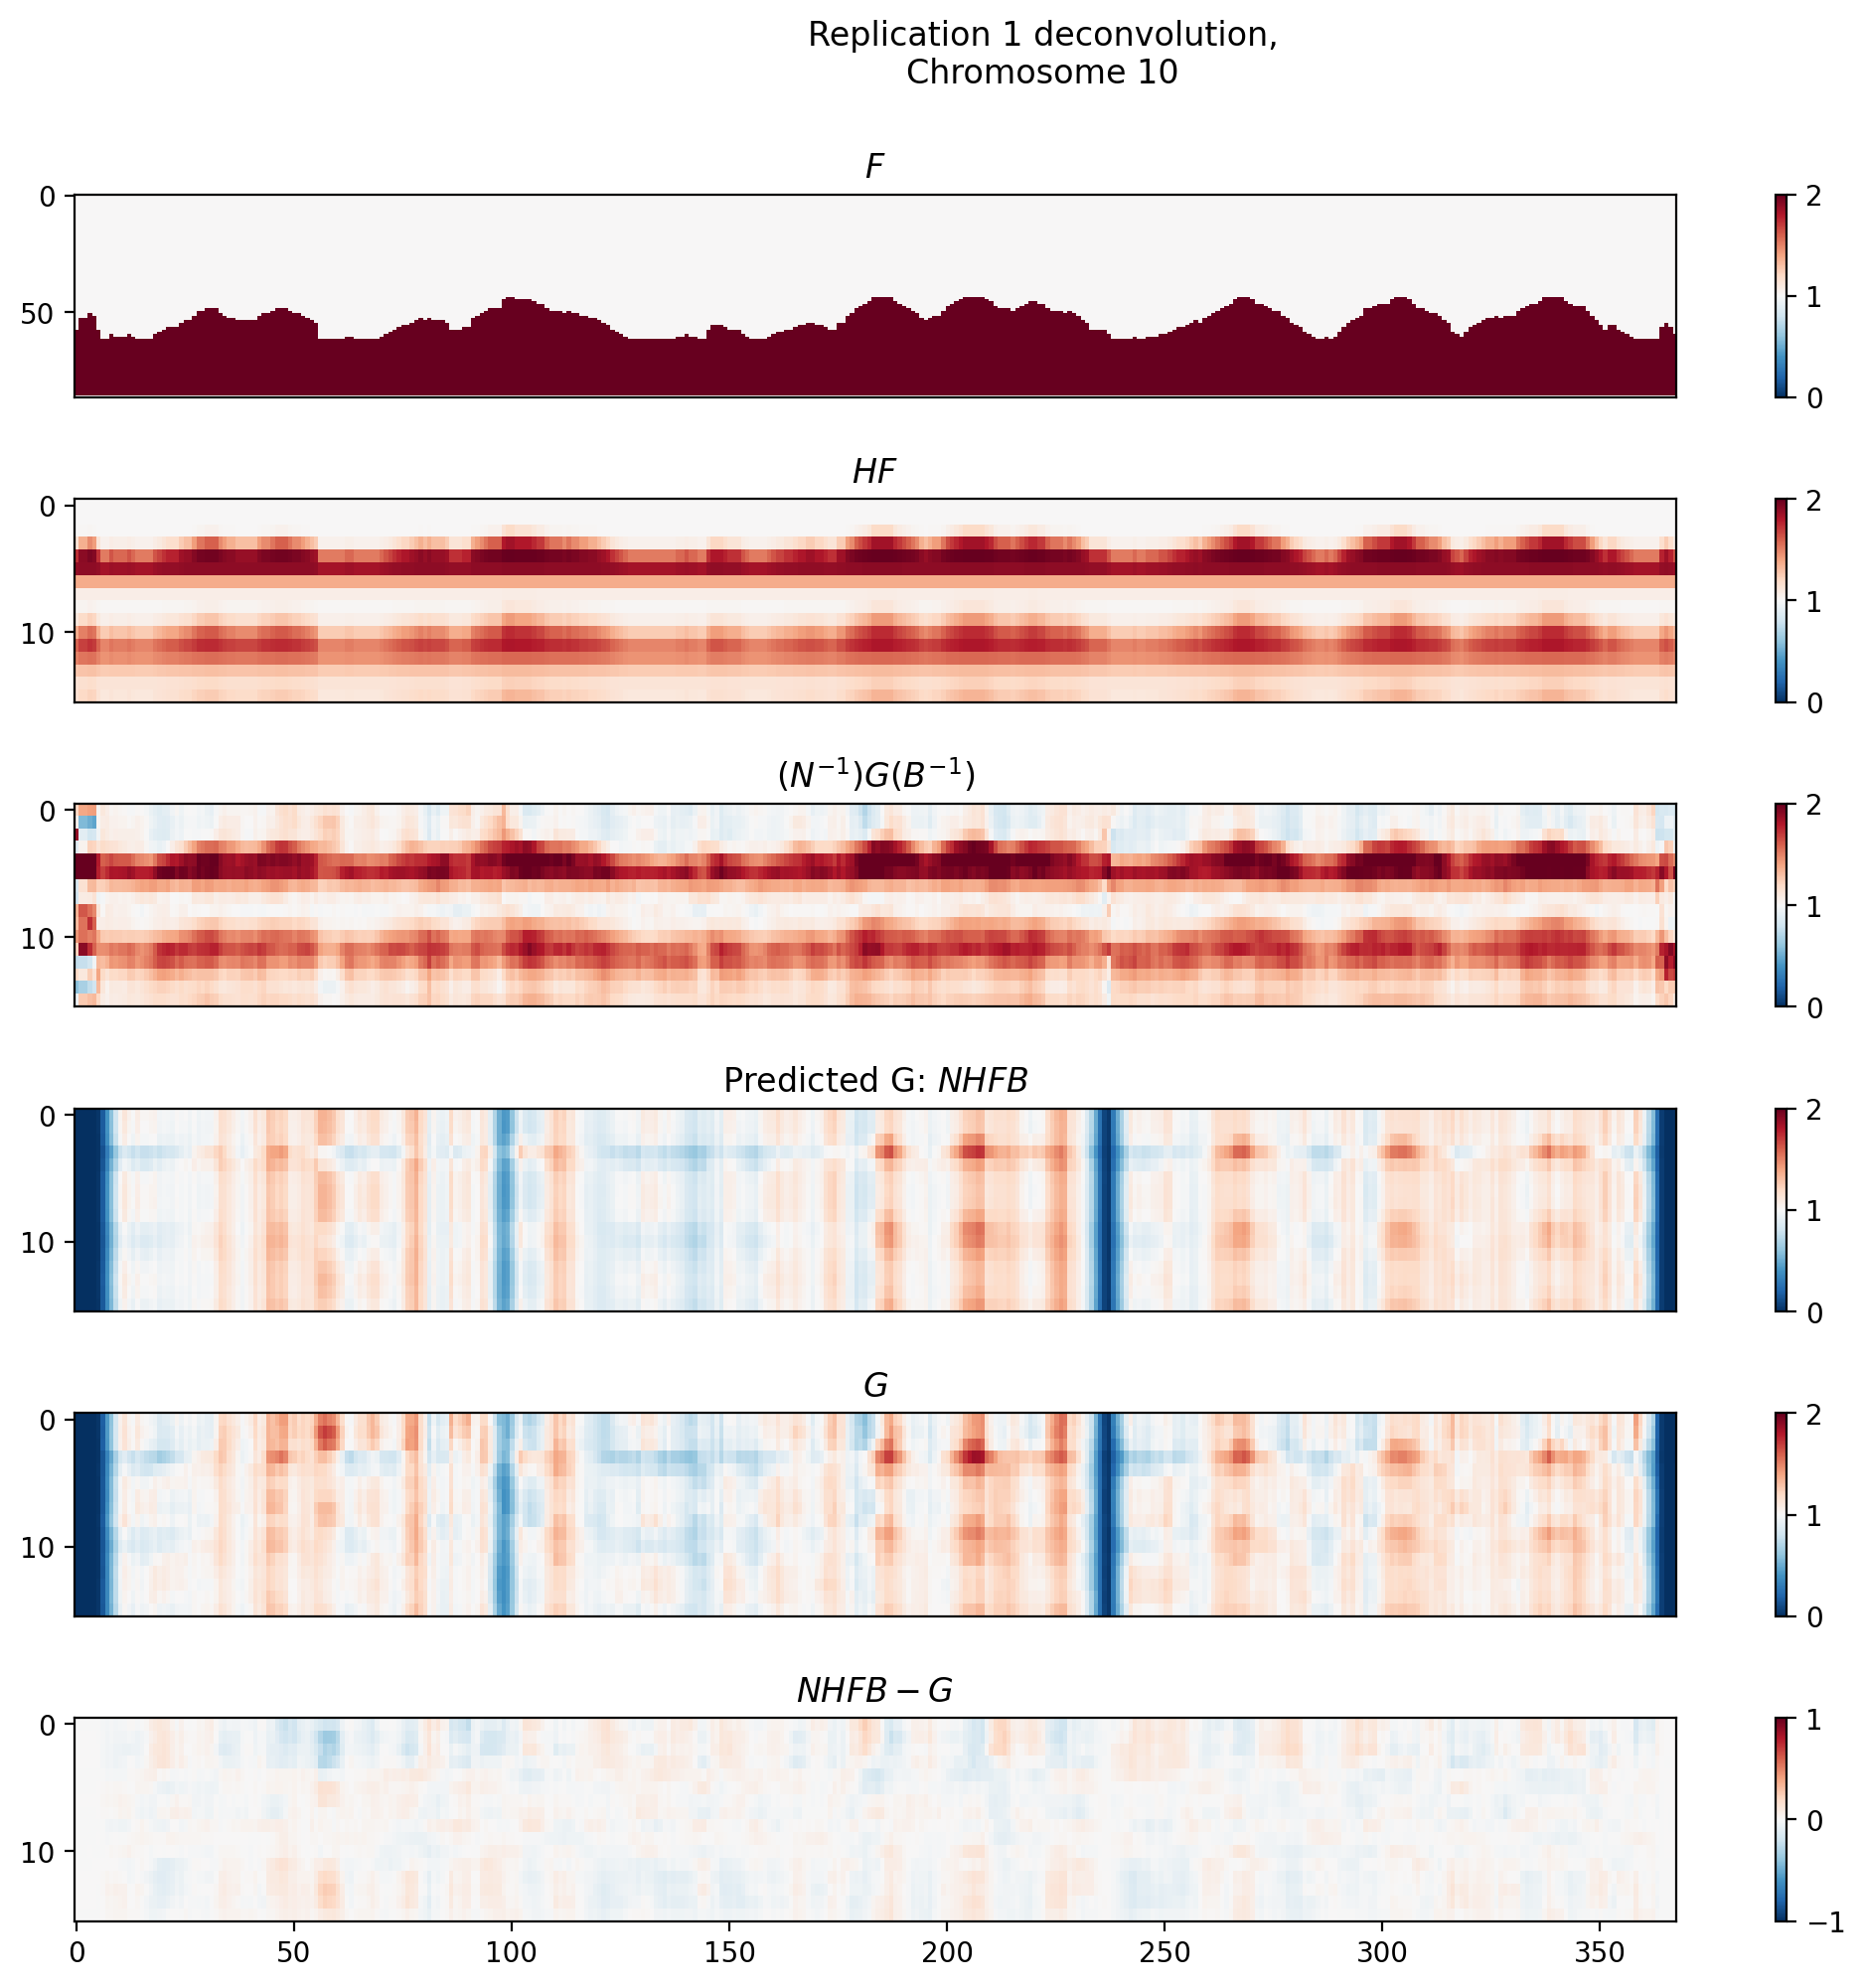

In [166]:
real_deconv1.plot_heatmaps()

In [167]:
optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv1.N,
    F=real_deconv1.F,
    B=real_deconv1.B,
    G=real_deconv1.G
)


In [169]:
from src.timer import Timer
from src.single_G1_config import calcH

timer = Timer()

num_epochs = 200
num_iterations_N_B = 5
update_params_df = pd.DataFrame()

N = real_deconv1.N
B = real_deconv1.B

optimizer = ParameterOptimizer(
    init_params_df=params_df,
    config=config,
    N=real_deconv1.N,
    F=real_deconv1.F,
    B=real_deconv1.B,
    G=real_deconv1.G
)

for epoch in range(num_epochs):
    print("Epoch: ", epoch)
    
    optimizer.optimize(maxiter=1000, verbose=True)

    real_deconv1.H = optimizer.current_H
        
    real_deconv1.iterative_deconvolution_updates(
        total_iterations=num_iterations_N_B, timer=timer,
        initial_B=B, initial_N=N)
    timer.print_time()
    
    params_row = pd.DataFrame([optimizer.params_df['value']], index=[epoch])
    params_row['opt_H_loss'] = optimizer.rn
    params_row['F_rn'] = real_deconv1.rn

    update_params_df = pd.concat([update_params_df, params_row])
    
    optimizer.N = real_deconv1.N
    optimizer.B = real_deconv1.B
    optimizer.F = real_deconv1.F
    
    N = real_deconv1.N
    B = real_deconv1.B

    print(update_params_df.iloc[-1])


Epoch:  0
Optimization [1]: Current loss: 0.0031466716980656784
Optimization [101]: Current loss: 0.003142776270655439
Optimization [201]: Current loss: 0.003141759717476282
Optimization [301]: Current loss: 0.0031365301742485234
Optimization terminated successfully.
         Current function value: 0.003136
         Iterations: 257
         Function evaluations: 395
Iteration 0
0/368 - 00:01:26.234
100/368 - 00:01:26.318
200/368 - 00:01:26.404
300/368 - 00:01:26.489
0.003126970037294665
Iteration completed 00:01:26.837, rn=0.003126970037294665
Iteration 1
0/368 - 00:01:26.838
100/368 - 00:01:26.919
200/368 - 00:01:26.999
300/368 - 00:01:27.078
0.003113290617428365
Iteration completed 00:01:27.484, rn=0.0031132906174283635
Iteration 2
0/368 - 00:01:27.485
100/368 - 00:01:27.566
200/368 - 00:01:27.646
300/368 - 00:01:27.726
0.003109282151015969
Iteration completed 00:01:27.980, rn=0.003109282151015969
Iteration 3
0/368 - 00:01:27.981
100/368 - 00:01:28.061
200/368 - 00:01:28.141
300/368

100/368 - 00:04:49.839
200/368 - 00:04:49.919
300/368 - 00:04:49.998
0.0031000379647525603
Iteration completed 00:04:50.068, rn=0.0031000379647525603
Iteration 3
0/368 - 00:04:50.069
100/368 - 00:04:50.149
200/368 - 00:04:50.229
300/368 - 00:04:50.308
0.0030999855113200197
Iteration completed 00:04:50.384, rn=0.00309998551132002
Iteration 4
0/368 - 00:04:50.385
100/368 - 00:04:50.464
200/368 - 00:04:50.544
300/368 - 00:04:50.623
0.0030999898184887495
Iteration completed 00:04:50.696, rn=0.0030999898184887495
00:04:50.696
mu0           7.332364e+00
lambda        6.785825e+01
delta         7.685298e-03
sigma0        5.175223e+00
sigmav        1.048197e-01
gamma1        4.645990e-01
gamma2        1.000000e+00
halted        7.319835e-07
opt_H_loss    3.098495e-03
F_rn          3.099990e-03
Name: 5, dtype: float64
Epoch:  6
Optimization [1]: Current loss: 0.0030999898184887495
Optimization [101]: Current loss: 0.0030984116447153797
Optimization terminated successfully.
         Current func

Optimization [1]: Current loss: 0.003094682997006457
Optimization [101]: Current loss: 0.003093656939727793
Optimization terminated successfully.
         Current function value: 0.003094
         Iterations: 84
         Function evaluations: 148
Iteration 0
0/368 - 00:08:23.449
100/368 - 00:08:23.529
200/368 - 00:08:23.608
300/368 - 00:08:23.688
0.003093599933438477
Iteration completed 00:08:23.766, rn=0.003093599933438476
Iteration 1
0/368 - 00:08:23.767
100/368 - 00:08:23.846
200/368 - 00:08:23.926
300/368 - 00:08:24.005
0.0030939961230454977
Iteration completed 00:08:24.079, rn=0.0030939961230454964
Iteration 2
0/368 - 00:08:24.080
100/368 - 00:08:24.159
200/368 - 00:08:24.239
300/368 - 00:08:24.319
0.0030934806513086338
Iteration completed 00:08:24.408, rn=0.003093480651308634
Iteration 3
0/368 - 00:08:24.409
100/368 - 00:08:24.488
200/368 - 00:08:24.567
300/368 - 00:08:24.646
0.003092868529627339
Iteration completed 00:08:24.816, rn=0.0030928685296273393
Iteration 4
0/368 - 00:08

100/368 - 00:10:32.200
200/368 - 00:10:32.280
300/368 - 00:10:32.360
0.0030885452754466423
Iteration completed 00:10:32.504, rn=0.0030885452754466423
00:10:32.504
mu0           8.146703e+00
lambda        6.811256e+01
delta         8.249221e-03
sigma0        5.083706e+00
sigmav        1.126610e-01
gamma1        4.733554e-01
gamma2        1.000000e+00
halted        6.788053e-07
opt_H_loss    3.088638e-03
F_rn          3.088545e-03
Name: 16, dtype: float64
Epoch:  17
Optimization [1]: Current loss: 0.0030885452754466423
Optimization [101]: Current loss: 0.0030877980062503103
Optimization terminated successfully.
         Current function value: 0.003088
         Iterations: 68
         Function evaluations: 126
Iteration 0
0/368 - 00:10:59.878
100/368 - 00:10:59.964
200/368 - 00:11:00.046
300/368 - 00:11:00.128
0.003087780714727529
Iteration completed 00:11:00.227, rn=0.0030877807147275302
Iteration 1
0/368 - 00:11:00.228
100/368 - 00:11:00.310
200/368 - 00:11:00.395
300/368 - 00:11:00.48

300/368 - 00:13:07.517
0.0030869459547611788
Iteration completed 00:13:07.639, rn=0.0030869459547611775
Iteration 2
0/368 - 00:13:07.640
100/368 - 00:13:07.720
200/368 - 00:13:07.800
300/368 - 00:13:07.880
0.0030871250900755035
Iteration completed 00:13:08.000, rn=0.003087125090075502
Iteration 3
0/368 - 00:13:08.001
100/368 - 00:13:08.081
200/368 - 00:13:08.161
300/368 - 00:13:08.241
0.003087394545812637
Iteration completed 00:13:08.414, rn=0.003087394545812638
Iteration 4
0/368 - 00:13:08.415
100/368 - 00:13:08.495
200/368 - 00:13:08.576
300/368 - 00:13:08.655
0.0030875610848023843
Iteration completed 00:13:08.779, rn=0.0030875610848023834
00:13:08.779
mu0           8.441548e+00
lambda        6.810399e+01
delta         7.708613e-03
sigma0        5.033174e+00
sigmav        1.147351e-01
gamma1        4.776135e-01
gamma2        1.000000e+00
halted        7.293565e-07
opt_H_loss    3.086668e-03
F_rn          3.087561e-03
Name: 22, dtype: float64
Epoch:  23
Optimization [1]: Current loss:

...

100/368 - 01:24:23.578
200/368 - 01:24:23.658
300/368 - 01:24:23.738
0.0031039191730319773
Iteration completed 01:24:24.003, rn=0.0031039191730319773
01:24:24.003
mu0           18.356880
lambda        68.041626
delta          0.001237
sigma0         5.118172
sigmav         0.116652
gamma1         0.628249
gamma2         1.000000
halted         0.000002
opt_H_loss     0.003103
F_rn           0.003104
Name: 175, dtype: float64
Epoch:  176
Optimization [1]: Current loss: 0.0031039191730319773
Optimization [101]: Current loss: 0.0031028881364437715
Optimization terminated successfully.
         Current function value: 0.003103
         Iterations: 78
         Function evaluations: 140
Iteration 0
0/368 - 01:24:55.296
100/368 - 01:24:55.376
200/368 - 01:24:55.456
300/368 - 01:24:55.536
0.003102841312966079
Iteration completed 01:24:55.903, rn=0.003102841312966079
Iteration 1
0/368 - 01:24:55.904
100/368 - 01:24:55.984
200/368 - 01:24:56.065
300/368 - 01:24:56.147
0.003105530588379976
Iterat

0.003106430296303574
Iteration completed 01:27:31.734, rn=0.0031064302963035753
Iteration 2
0/368 - 01:27:31.734
100/368 - 01:27:31.815
200/368 - 01:27:31.895
300/368 - 01:27:31.975
0.0031060254325488592
Iteration completed 01:27:32.074, rn=0.0031060254325488606
Iteration 3
0/368 - 01:27:32.076
100/368 - 01:27:32.156
200/368 - 01:27:32.236
300/368 - 01:27:32.316
0.00310553549444351
Iteration completed 01:27:32.490, rn=0.003105535494443509
Iteration 4
0/368 - 01:27:32.492
100/368 - 01:27:32.571
200/368 - 01:27:32.651
300/368 - 01:27:32.731
0.003105473514710866
Iteration completed 01:27:32.878, rn=0.0031054735147108643
01:27:32.878
mu0           18.911617
lambda        68.029344
delta          0.001128
sigma0         5.094564
sigmav         0.116316
gamma1         0.636337
gamma2         1.000000
halted         0.000002
opt_H_loss     0.003103
F_rn           0.003105
Name: 181, dtype: float64
Epoch:  182
Optimization [1]: Current loss: 0.003105473514710866
Optimization [101]: Current los

Optimization [101]: Current loss: 0.0031079801566312225
Optimization terminated successfully.
         Current function value: 0.003108
         Iterations: 63
         Function evaluations: 116
Iteration 0
0/368 - 01:30:26.110
100/368 - 01:30:26.194
200/368 - 01:30:26.277
300/368 - 01:30:26.359
0.0031079683337201162
Iteration completed 01:30:26.542, rn=0.003107968333720119
Iteration 1
0/368 - 01:30:26.543
100/368 - 01:30:26.625
200/368 - 01:30:26.705
300/368 - 01:30:26.785
0.0031107131868473134
Iteration completed 01:30:26.905, rn=0.0031107131868473134
Iteration 2
0/368 - 01:30:26.907
100/368 - 01:30:26.987
200/368 - 01:30:27.068
300/368 - 01:30:27.148
0.003110634014853722
Iteration completed 01:30:27.271, rn=0.003110634014853721
Iteration 3
0/368 - 01:30:27.272
100/368 - 01:30:27.352
200/368 - 01:30:27.432
300/368 - 01:30:27.511
0.003110284104594321
Iteration completed 01:30:27.691, rn=0.0031102841045943215
Iteration 4
0/368 - 01:30:27.692
100/368 - 01:30:27.772
200/368 - 01:30:27.85

100/368 - 01:32:49.476
200/368 - 01:32:49.556
300/368 - 01:32:49.636
0.00310862071818066
Iteration completed 01:32:49.998, rn=0.0031086207181806585
01:32:49.998
mu0           19.911171
lambda        68.007978
delta          0.000999
sigma0         5.022701
sigmav         0.115477
gamma1         0.652162
gamma2         1.000000
halted         0.000002
opt_H_loss     0.003110
F_rn           0.003109
Name: 192, dtype: float64
Epoch:  193
Optimization [1]: Current loss: 0.00310862071818066
Optimization [101]: Current loss: 0.003107530999446652
Optimization terminated successfully.
         Current function value: 0.003107
         Iterations: 59
         Function evaluations: 116
Iteration 0
0/368 - 01:33:16.142
100/368 - 01:33:16.221
200/368 - 01:33:16.304
300/368 - 01:33:16.385
0.003107454145104182
Iteration completed 01:33:16.675, rn=0.003107454145104182
Iteration 1
0/368 - 01:33:16.677
100/368 - 01:33:16.756
200/368 - 01:33:16.836
300/368 - 01:33:16.917
0.0031105353012294513
Iteration 

0/368 - 01:35:31.953
100/368 - 01:35:32.033
200/368 - 01:35:32.114
300/368 - 01:35:32.193
0.00310943703312634
Iteration completed 01:35:32.339, rn=0.00310943703312634
Iteration 3
0/368 - 01:35:32.341
100/368 - 01:35:32.420
200/368 - 01:35:32.500
300/368 - 01:35:32.580
0.0031087489065533187
Iteration completed 01:35:32.724, rn=0.0031087489065533195
Iteration 4
0/368 - 01:35:32.726
100/368 - 01:35:32.805
200/368 - 01:35:32.886
300/368 - 01:35:32.966
0.003108464691362801
Iteration completed 01:35:33.181, rn=0.0031084646913628012
01:35:33.181
mu0           20.460316
lambda        67.975112
delta          0.000929
sigma0         4.997399
sigmav         0.114735
gamma1         0.660341
gamma2         1.000000
halted         0.000002
opt_H_loss     0.003107
F_rn           0.003108
Name: 198, dtype: float64
Epoch:  199
Optimization [1]: Current loss: 0.003108464691362801
Optimization [101]: Current loss: 0.003107242646633635
Optimization terminated successfully.
         Current function value

[autoreload of src.RealDataReplication failed: Traceback (most recent call last):
  File "/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 273, in check
    superreload(m, reload, self.old_objects)
  File "/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 471, in superreload
    module = reload(module)
  File "/Users/trung/opt/anaconda3/envs/cell-cycle-deconvolution/lib/python3.8/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 604, in _exec
  File "<frozen importlib._bootstrap_external>", line 843, in exec_module
  File "<frozen importlib._bootstrap>", line 219, in _call_with_frames_removed
  File "/Users/trung/Research/deconvolution-python/src/RealDataReplication.py", line 7, in <module>
    from src.replication_deconvolution_solver import deconvolve_replication

Text(0.5, 0.98, 'Cell cycle parameter updates, 200 epochs')

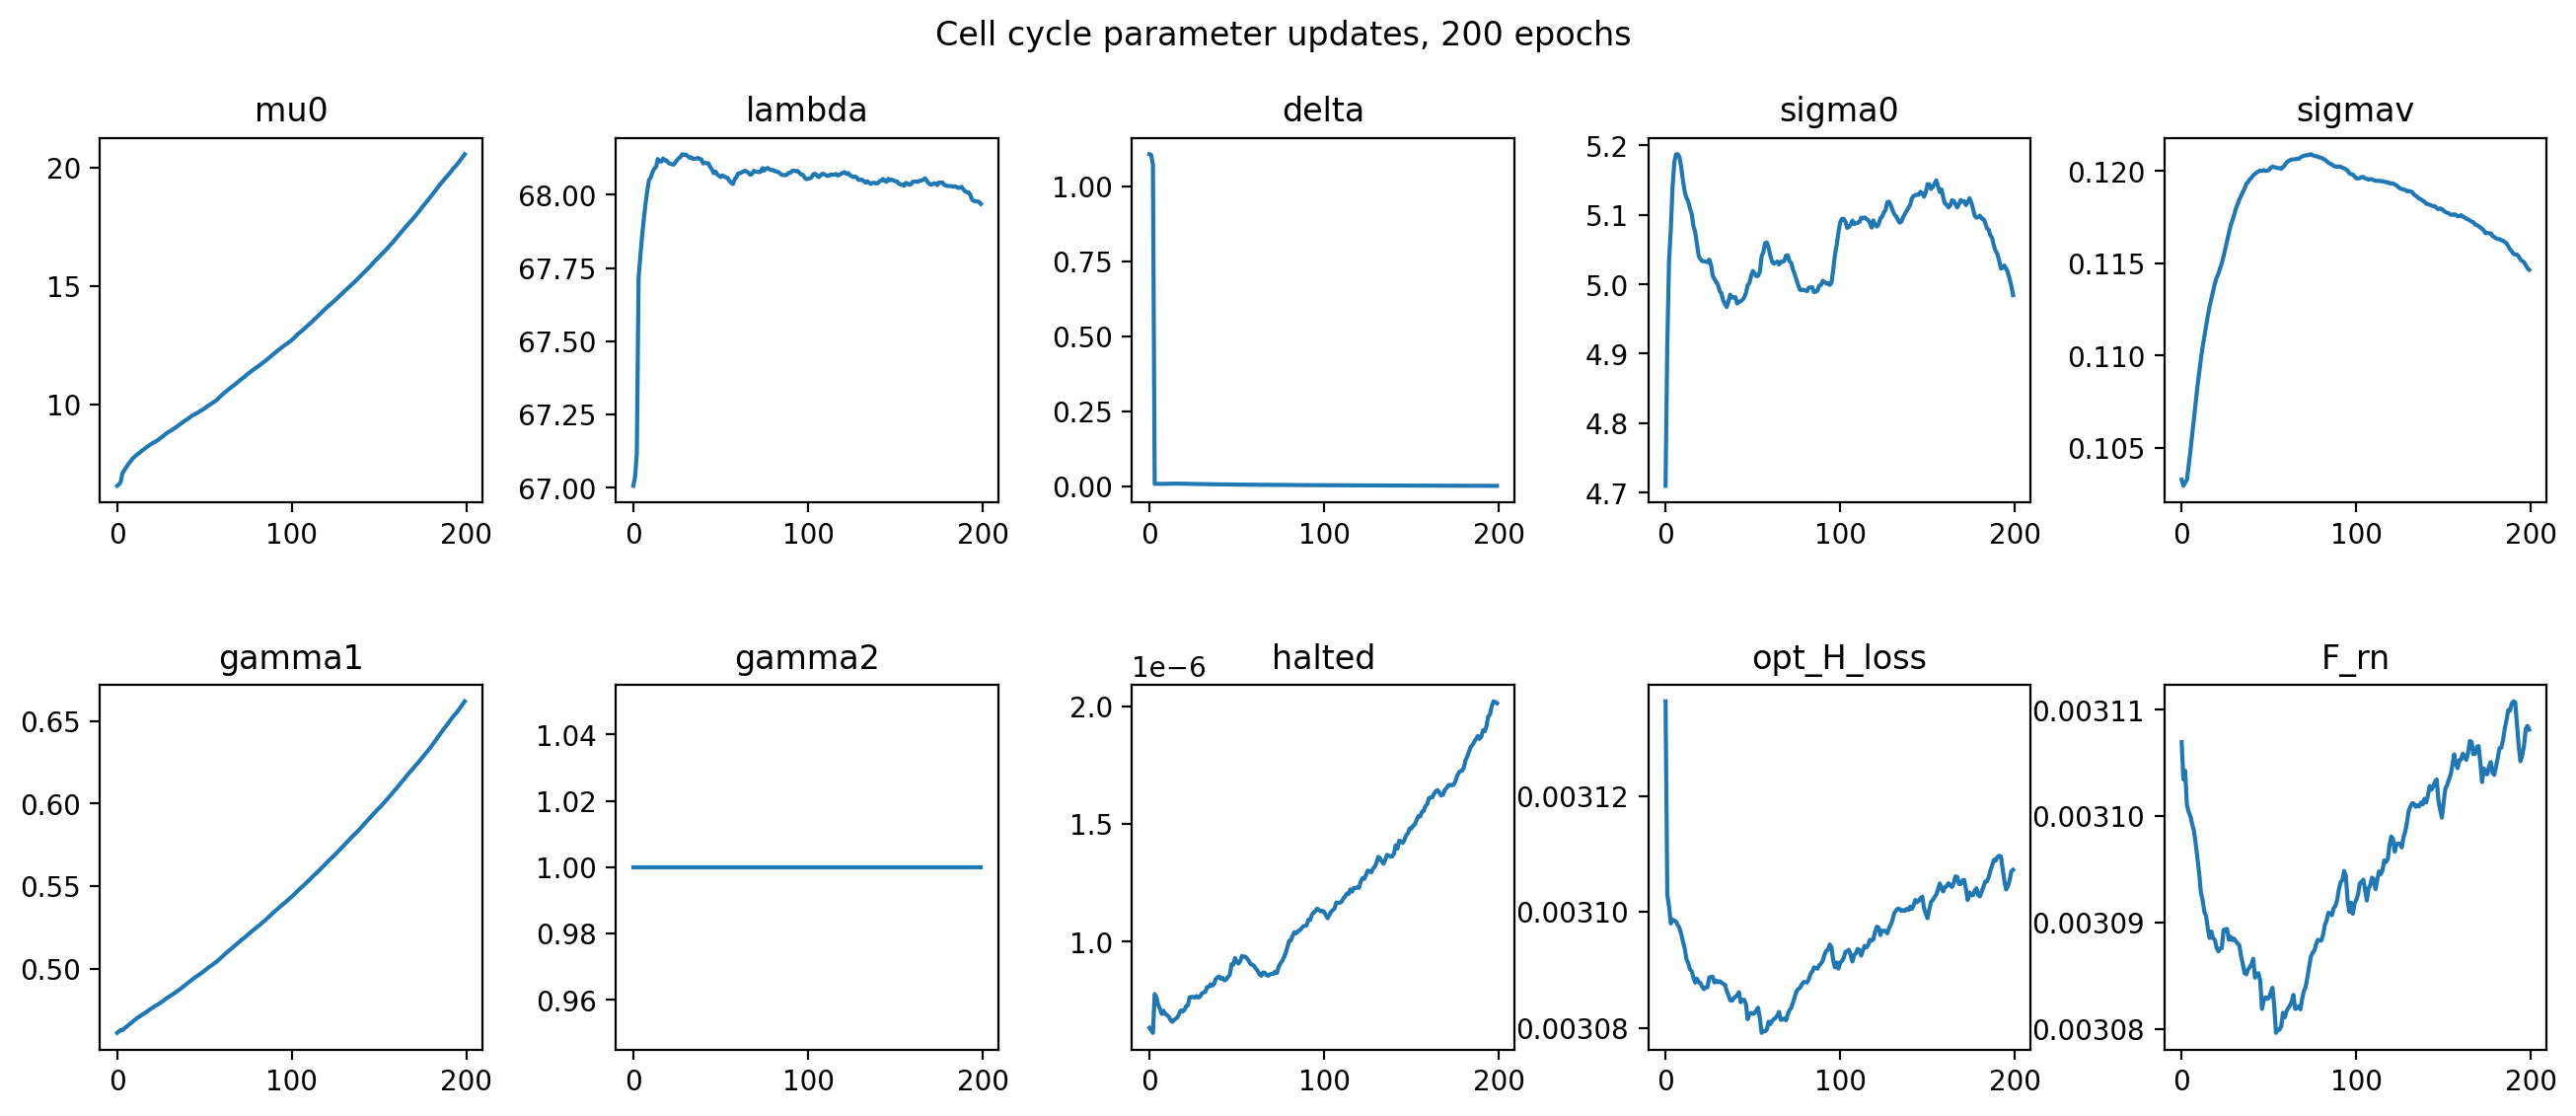

In [170]:
r, c = 2, 5

plt.figure(figsize=(16, 6))

for i, param in enumerate(update_params_df.columns):
        
    plt.subplot(r, c, i+1)
    plt.plot(update_params_df[param])
    plt.title(param)
    
plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.suptitle(f"Cell cycle parameter updates, {num_epochs} epochs")

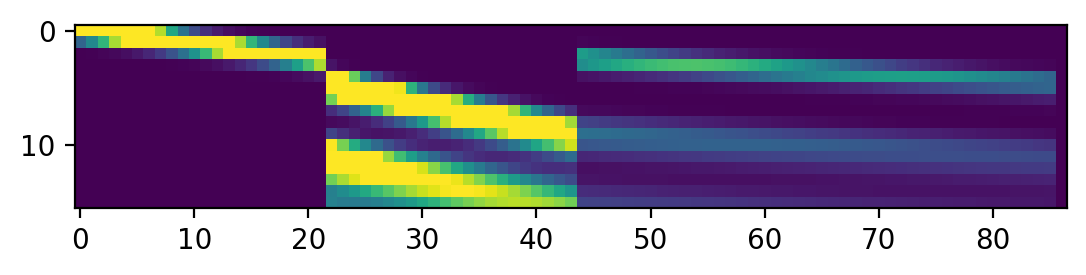

In [171]:
plt.imshow(real_deconv1.H, vmax=0.05)

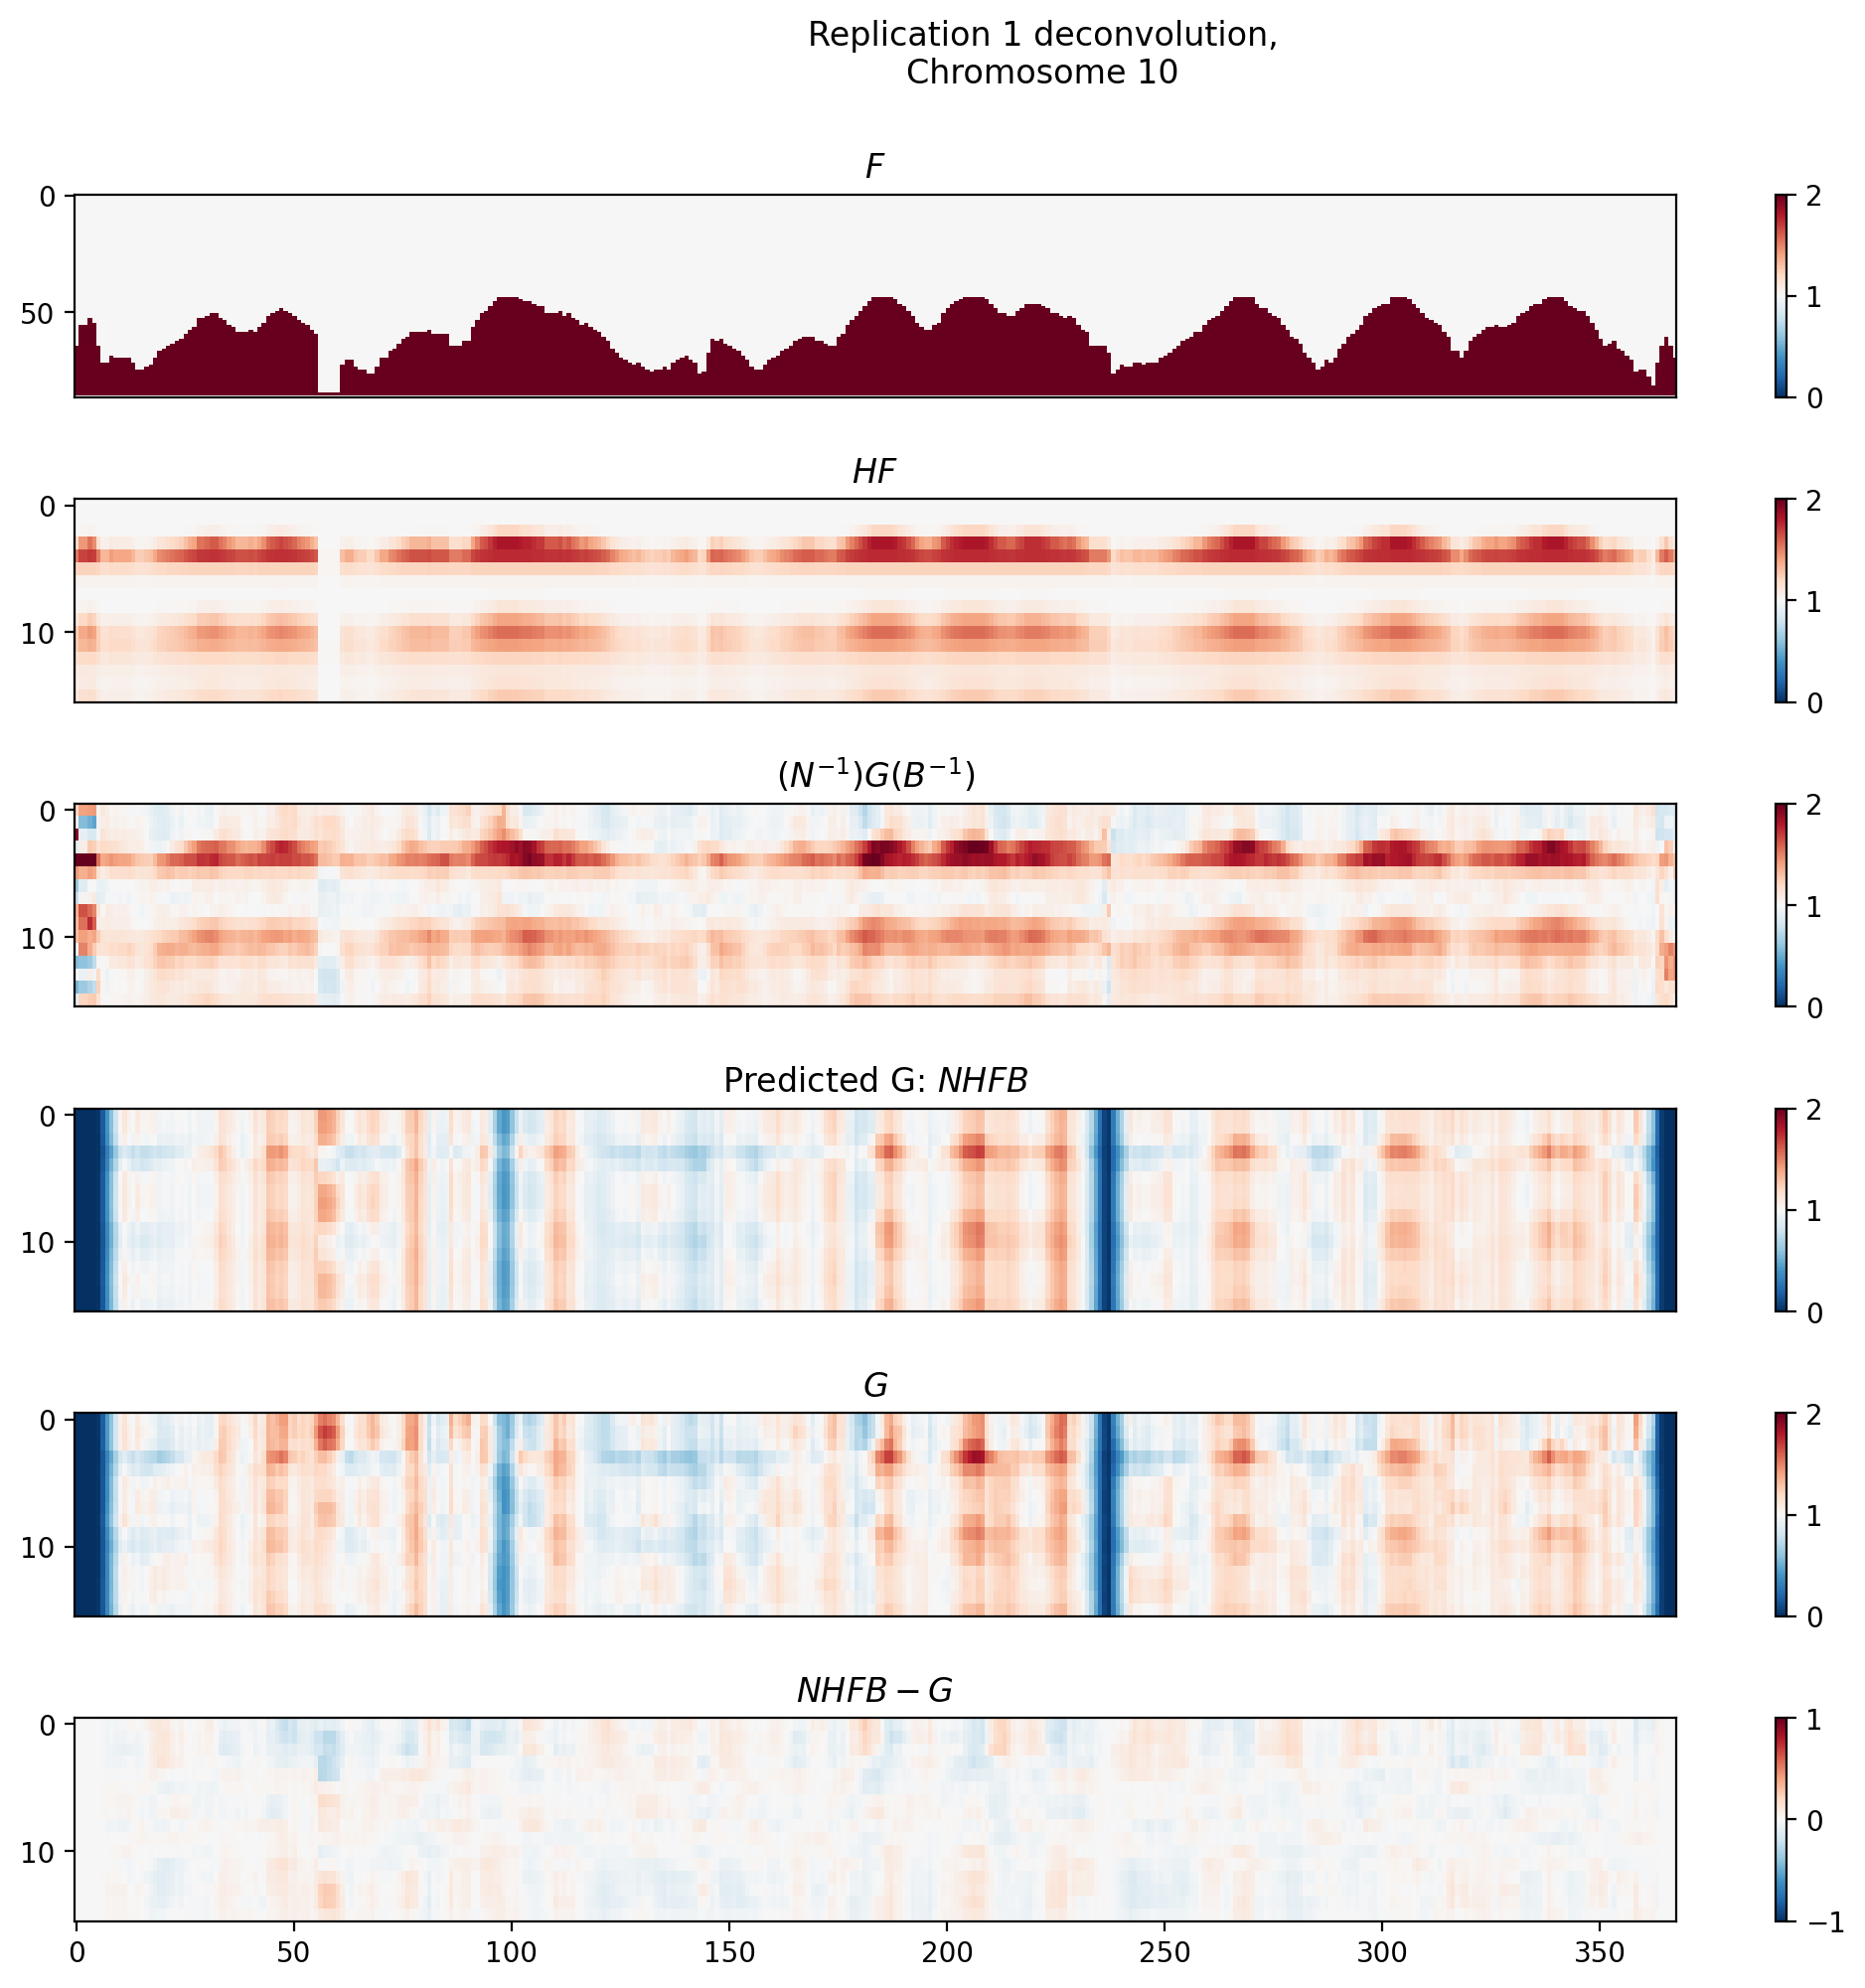

In [177]:
real_deconv1.plot_heatmaps()

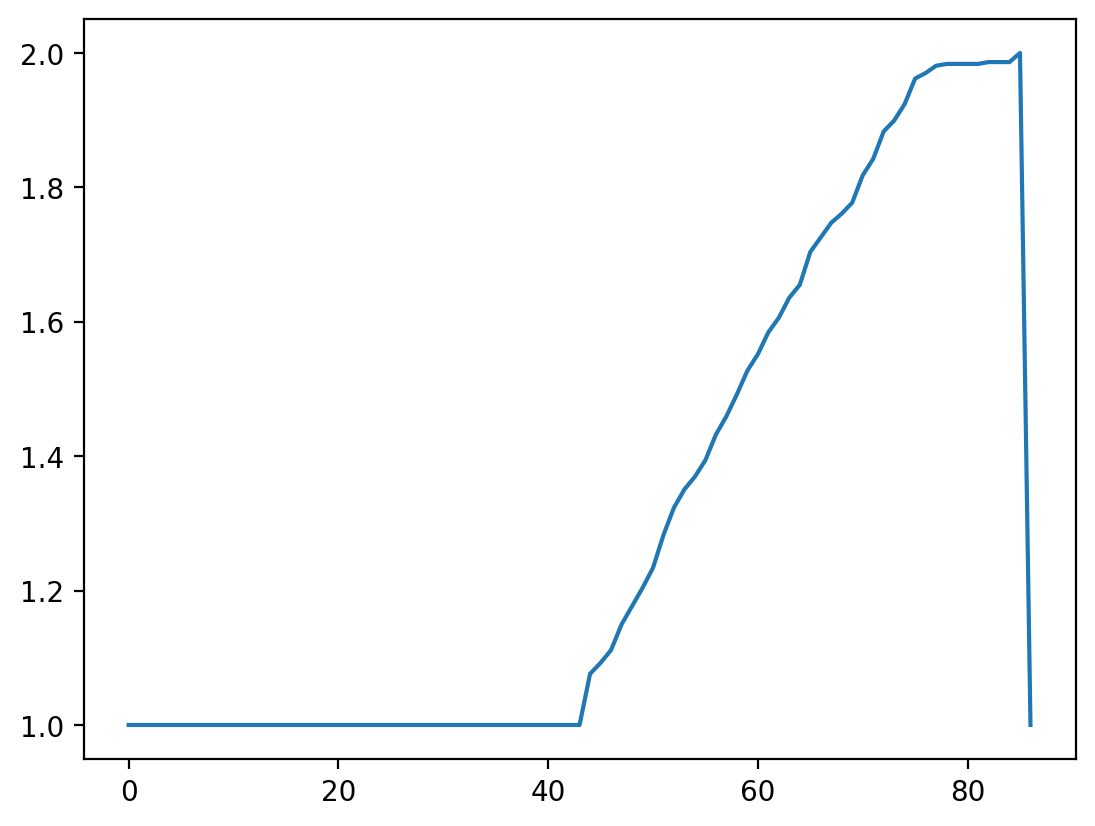

In [173]:
plt.plot(real_deconv1.F.mean(axis=1))

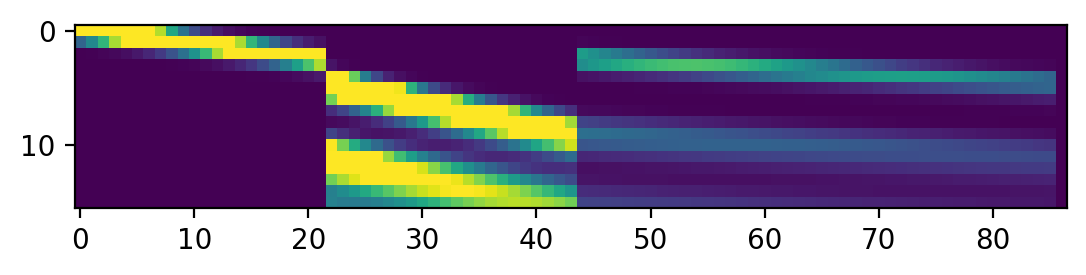

In [174]:
plt.imshow(config.H, vmax=0.05)

In [175]:
config.params_dic

{'mu0': 20.555006273737142,
 'delta': 0.0009143303515680489,
 'sigma0': 4.984272422353337,
 'sigmav': 0.11464386032695131,
 'lambda': 67.96844763366379,
 'gamma1': 0.6618773133928479,
 'gamma2': 1.0,
 'halted': 2.0125896788921646e-06,
 'alpha': 0}

In [176]:
# gamma1 appears to be estimated much larger than expected 
# (as 41% into the cell cycle, this doesn't seems reasonable.

# Remember to remove low coverage windows, and address alpha factor affected windows.....
# should we remove these from this estimation?

